# Hard coal NPV simulation

Run the hard coal electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_model import simulate_hard_coal_npv

In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_hard_coal_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2220.816977,37.821378,4.881391,2.657779,...,94070000.0,9.224726e+06,4.881391e+06,2.441489e+07,6.730721e+07,-1.175822e+07,-6.671790e+08,25000000.0,-26.687160,-0.000027
1,1,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2066.575591,42.383454,5.309390,2.591513,...,94070000.0,1.033743e+07,5.309390e+06,2.677252e+07,7.188937e+07,-2.023870e+07,-7.200864e+08,25000000.0,-28.803458,-0.000029
2,2,hard_coal,1000000.0,4100.0,243.902439,243902.439024,1907.200817,38.908658,5.583599,2.590894,...,94070000.0,9.489917e+06,5.583599e+06,3.170331e+07,7.036829e+07,-2.307511e+07,-7.114926e+08,25000000.0,-28.459704,-0.000028
3,3,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2267.275351,39.151010,5.113733,2.518848,...,94070000.0,9.549027e+06,5.113733e+06,3.148639e+07,6.742117e+07,-1.950032e+07,-7.611555e+08,25000000.0,-30.446222,-0.000030
4,4,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2248.202713,32.761404,5.026702,2.580801,...,94070000.0,7.990586e+06,5.026702e+06,2.791242e+07,7.198489e+07,-1.884459e+07,-7.495039e+08,25000000.0,-29.980158,-0.000030


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,-715.959422,-28.638377,-0.000029
std,78.500630,3.140025,0.000003
min,-1107.950037,-44.318001,-0.000044
5%,-854.403234,-34.176129,-0.000034
50%,-710.763011,-28.430520,-0.000028
95%,-595.452128,-23.818085,-0.000024
max,-495.538048,-19.821522,-0.000020


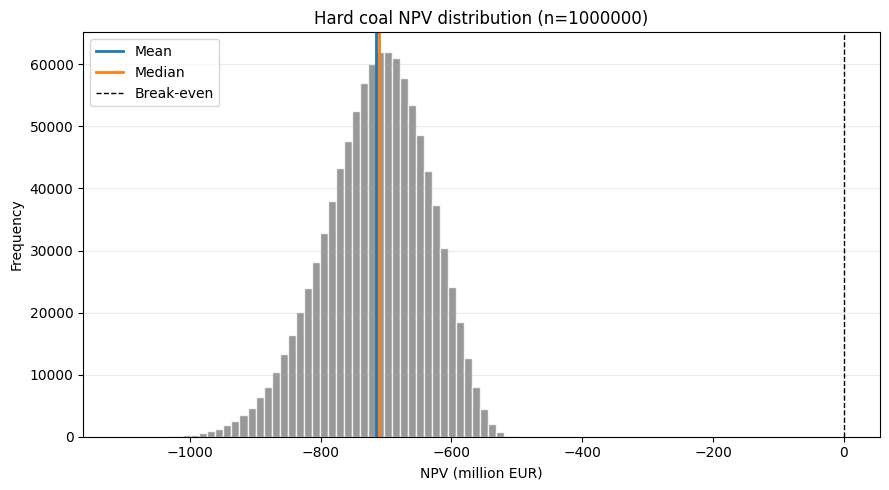

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

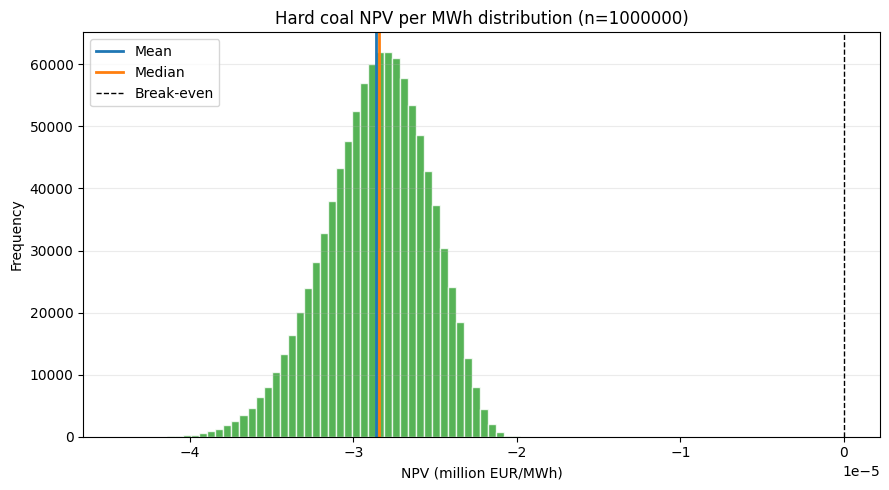

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         9.325785
annual_variable_opex_eur      5.166872
annual_fuel_cost_eur         31.083623
annual_emissions_cost_eur    69.866877
annual_net_cash_flow_eur    -21.373157
Name: Mean annual value, million EUR, dtype: float64